<a href="https://colab.research.google.com/github/achmadfadhil/fi1101-04-2023-1/blob/main/final_report_format_10223006_10223045.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteksi Risiko Korupsi pada Proyek Pengadaan Menggunakan Artificial Neural Network
>

Author | ID | GitHub | Role
:- | :-: | :- | :-
Ahmad Fadillah | 10223006 | https://github.com/achmadfadhil | Model Development, Evaluation, code, training ANN
Naufal Aulia Pramadahana| 10223045 | https://github.com/naufal170706| Data Acquisition, Preprocessing, code, Feature Engineering ,dan Proxy Labeling




## Pendahuluan


Proses pengadaan barang dan jasa (tender) sering kali rentan terhadap praktik persekongkolan atau manipulasi (fraud). Mendeteksi indikasi kecurangan secara manual pada ribuan dokumen proyek tidak hanya memakan waktu, tetapi juga rentan terhadap human error. Untuk mengatasi masalah ini, pendekatan yang dilakukan adalah membangun sistem deteksi otomatis menggunakan algoritma cerdas. Sistem ini diawali dengan pendekatan berbasis aturan (rule-based) yang memberikan skor Red Flag pada kondisi anomali seperti: minimnya peserta kompetisi, selisih penawaran harga yang sangat tipis, waktu tender yang terlalu singkat, serta dominasi pemenang berulang. Data yang telah melalui sistem scoring ini kemudian dijadikan bahan pembelajaran bagi model Machine Learning untuk mendeteksi probabilitas risiko kecurangan secara otomatis dan terukur.

Kasus ini diselesaikan melalui pendekatan Klasifikasi (Classification), lebih spesifiknya adalah Klasifikasi Biner (Binary Classification). Tujuan utama dari model ini adalah memisahkan data proyek ke dalam dua kelas atau kategori yang tegas: kelas 0 untuk proyek yang masuk kategori aman, dan kelas 1 untuk proyek yang terindikasi memiliki risiko tinggi

Sistem ini menggunakan algoritma Supervised Learning (Pembelajaran Terarah). Model dilatih menggunakan dataset historis yang sudah memiliki "kunci jawaban" atau label target (kolom Target). Melalui data latih tersebut, algoritma belajar mengenali pola matematis dari variabel input untuk kemudian menebak label pada data baru yang belum pernah dilihat sebelumnya.

Untuk memecahkan masalah ini, model yang diimplementasikan adalah Artificial Neural Network (ANN), secara khusus menggunakan arsitektur Multilayer Perceptron (MLP). Jaringan saraf tiruan ini dipilih karena kemampuannya yang sangat baik dalam memetakan hubungan non-linear dan kompleks antar variabel tender, menggunakan mekanisme kompresi informasi melalui lapisan tersembunyi (hidden layers) untuk menghasilkan tingkat keyakinan (probabilitas) risiko fraud.

Pengembangan model, prapemrosesan data, hingga tahap pengujian dilakukan menggunakan lingkungan pemrograman Python secara lokal (seperti Jupyter Notebook atau IDE Code Editor pendukung Data Science), yang diintegrasikan langsung dengan sistem penyimpanan data lokal (local directory).

Sistem analitik ini dibangun menggunakan ekosistem library standar yang tangguh:

1. Pandas: Berperan vital dalam membaca dataset mentah, manipulasi tabel (Dataframe), pembuatan fitur perhitungan Red Flag, dan penulisan hasil akhir ke format Excel/CSV.

2. NumPy: Digunakan untuk komputasi matematis yang cepat dan penerapan logika kondisional yang efisien dalam pembentukan matriks data.

3. Scikit-Learn (Sklearn): Merupakan library inti dari otak AI ini. Modul ini menyediakan alat untuk menormalkan skala data (StandardScaler), membagi set data latih dan uji (train_test_split), membangun arsitektur ANN (MLPClassifier), serta mengevaluasi performa model melalui metrik presisi dan akurasi (classification_report).

Pendekatan dalam tugas ini merujuk pada standar analisis investigasi yang umum digunakan dalam mendeteksi anomali lelang (seperti anomali HPS dan jumlah peserta). Sedangkan dari sisi komputasi, penggunaan lapisan tersembunyi berstruktur kerucut pada model MLP merujuk pada literatur standar Deep Learning untuk ekstraksi fitur (feature extraction), dibantu dengan teknik standardisasi Z-score agar jaringan saraf dapat mencapai konvergensi (fokus pembelajaran) yang lebih optimal dan akurat saat proses pelatihan.

## Metode
Penelitian ini menggunakan model Artificial Neural Network (ANN) dengan algoritma spesifik Multilayer Perceptron (MLP) untuk melakukan tugas klasifikasi. MLP adalah jenis jaringan saraf tiruan feedforward, di mana aliran data bergerak satu arah dari simpul masukan (input) ke simpul keluaran (output) tanpa adanya putaran umpan balik (loop). Model ini dipilih karena kemampuannya yang tangguh dalam mempelajari dan memetakan hubungan non-linear yang kompleks dari berbagai variabel pelelangan untuk mendeteksi anomali atau risiko kecurangan secara prediktif.

Topologi jaringan yang dibangun pada model ini mengadopsi struktur kompresi informasi dengan konfigurasi 5-8-4-1. Rincian arsitekturnya adalah sebagai berikut:

1. Input Layer: Terdiri dari 5 neuron yang mewakili lima fitur prediktor (Nilai HPS, Jumlah Peserta, Selisih Penawaran, Waktu Tender, dan Riwayat Menang).

2. Hidden Layers: Terdiri dari dua lapisan tersembunyi yang masing-masing memiliki 8 neuron dan 4 neuron. Struktur yang mengerucut (bottleneck) ini dirancang untuk menyaring kebisingan data (noise) dan mengekstraksi inti pola kecurangan. Lapisan ini menggunakan fungsi aktivasi ReLU (Rectified Linear Unit) agar model mampu mempelajari pola non-linear.

3. Output Layer: Terdiri dari 1 neuron tunggal yang bertugas mengeluarkan probabilitas akhir. Nilai keluaran dipetakan ke dalam dua kelas diskrit (0 untuk Aman, 1 untuk Risiko Tinggi) menggunakan ambang batas klasifikasi standar.

Meskipun bertenaga, model ANN/MLP yang digunakan memiliki beberapa keterbatasan inheren:

1. Sifat Black-Box: Sulit untuk diinterpretasikan atau dijelaskan secara matematis proses pengambilan keputusan di setiap neuronnya (berbeda dengan Decision Tree atau regresi linear di mana bobot fitur sangat transparan).

2. Sensitivitas terhadap Skala Data: Model ini sangat bergantung pada prapemrosesan data. Jika fitur tidak dinormalisasi (dalam kasus ini telah ditangani menggunakan StandardScaler), fitur dengan rentang nilai besar (seperti Nilai HPS) akan mendominasi dan mengacaukan pembaruan bobot saat pelatihan.

3. Risiko Overfitting: Pada dataset yang relatif kecil, konfigurasi lapisan tersembunyi yang terlalu kompleks dapat membuat model cenderung menghafal data latih alih-alih mempelajari pola umumnya, meskipun pada model ini sudah diminimalkan dengan desain arsitektur yang sederhana.


Dalam konteks klasifikasi Machine Learning, hyperplane adalah batas keputusan (decision boundary) yang memisahkan kelas-kelas data. Berbeda dengan model regresi logistik yang memiliki hyperplane linier (datar/lurus), penggunaan fungsi aktivasi ReLU pada hidden layers ANN memungkinkan model untuk menciptakan prediksi hyperplane yang non-linear dan multi-dimensi.

Hyperplane pada ruang fitur 5 dimensi ini akan membengkok dan menyesuaikan diri untuk membungkus titik-titik data (proyek) yang memiliki fitur kombinasi berisiko tinggi, memisahkannya secara dinamis dari titik-titik data proyek yang berstatus wajar.

Untuk mengukur seberapa baik kinerja hyperplane dalam memisahkan data klasifikasi biner tersebut, model dievaluasi menggunakan Confusion Matrix dan matriks performa klasifikasi. Confusion Matrix membagi tebakan model menjadi empat kuadran: True Positive (Tebakan Risiko Benar), True Negative (Tebakan Aman Benar), False Positive (Aman ditebak Risiko), dan False Negative (Risiko ditebak Aman).

Dari matriks tersebut, diekstraksi metrik evaluasi utama berikut:

1. Precision: Mengukur tingkat ketepatan tebakan positif.

2. Recall (Sensitivity): Metrik paling krusial dalam deteksi kecurangan.

3. F1-Score: Rata-rata harmonik antara Precision dan Recall, memberikan pandangan performa model yang seimbang terutama bila jumlah proyek wajar dan proyek curang tidak seimbang.

## Model
Model yang digunakan dalam pemrosesan data ini adalah Artificial Neural Network (ANN) dengan jenis arsitektur Multilayer Perceptron (MLP). Jaringan saraf ini dirancang secara spesifik menggunakan struktur tiga lapisan (three layers) yang saling terhubung secara penuh (fully connected).

1. Lapisan Masukan (Input Layer): Terdiri dari tepat dua neuron. Lapisan ini bertugas sebagai pintu masuk data yang menerima dua variabel fitur prediktor, yang secara matematis dinotasikan sebagai $X_1$ dan $X_2$.Lapisan Tersembunyi
2. (Hidden Layer): Jaringan ini menggunakan satu buah lapisan tersembunyi tunggal yang berisi empat neuron. Lapisan ini berfungsi sebagai pusat pemrosesan komputasi (bottleneck), di mana informasi dari $X_1$ dan $X_2$ dikalikan dengan bobot (weights), ditambahkan bias, dan dilewatkan pada fungsi aktivasi untuk mengenali pola data yang non-linear.Lapisan Keluaran
3. (Output Layer): Terdiri dari satu neuron tunggal. Neuron terakhir ini mengonsolidasikan semua informasi yang telah diproses oleh lapisan tersembunyi untuk menghasilkan satu nilai prediksi akhir atau target keluaran, yang dinotasikan sebagai Y. Untuk detailnya bisa dilihat pada Figure 1.

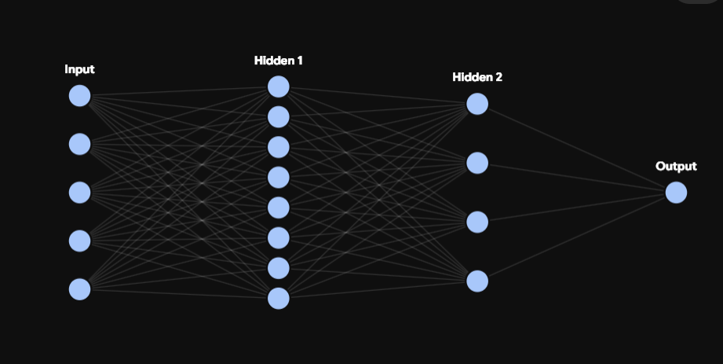

Bentuk jaringan saraf buatan memiliki skema 5-8-4-1, yang berarti terdiri dari 4 lapisan utama:

1. Input Layer (Lapisan Masukan): Terdapat 5 Neuron.
Jumlah ini tidak ditulis manual di parameter, melainkan otomatis menyesuaikan dengan jumlah fitur (X) yang kamu berikan ke AI untuk belajar, yaitu 5 variabel: Nilai_HPS_Miliar, Jumlah_Peserta, Selisih_Penawaran_%, Waktu_Tender_Hari, dan Riwayat_Menang_Sama.

2. idden Layers (Lapisan Tersembunyi): Terdapat 2 Lapisan.
Ini adalah inti dari pertanyaannya. Berdasarkan bagian kodemu hidden_layer_sizes=(8, 4), arsitekturnya sengaja dibuat mengerucut untuk menyaring informasi:

  a. Hidden Layer 1: Memiliki 8 neuron.

  b. Hidden Layer 2: Memiliki 4 neuron.

3. Output Layer (Lapisan Keluaran): Terdapat 1 Neuron.
Karena tugas akhir model ini adalah klasifikasi biner (menebak kelas 0 "Aman" atau 1 "Risiko Tinggi"), lapisan paling ujung hanya membutuhkan 1 neuron. Neuron ini bertugas mengeluarkan nilai probabilitas.

### Matriks Evaluasi


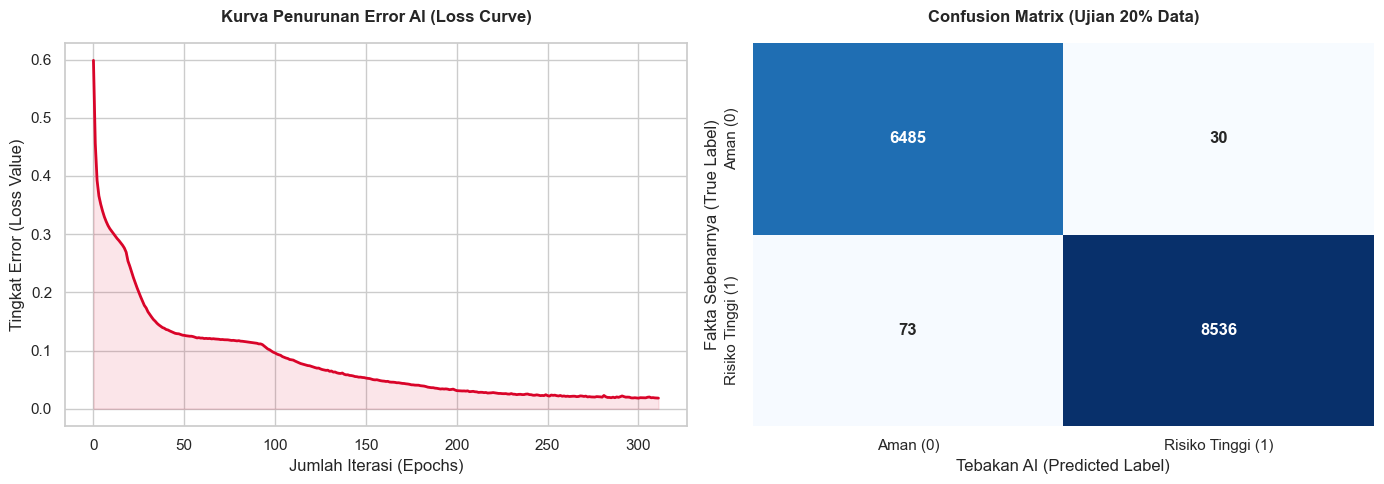


#### Rincian Tebakan AI (Kuadran)
Matriks ini membandingkan Tebakan AI (sumbu X di bawah) dengan Fakta Sebenarnya (sumbu Y di kiri).

1. Kiri Atas (6485) - True Negative

Artinya: AI menebak proyek Aman (0), dan faktanya proyek tersebut memang Aman (0).

Status: Tebakan Benar.

2. Kanan Bawah (8536) - True Positive

Artinya: AI menebak proyek Risiko Tinggi (1), dan faktanya proyek tersebut memang Risiko Tinggi (1).

Status: Tebakan Benar.

3. Kanan Atas (30) - False Positive (Alarm Palsu)

Artinya: AI menebak proyek Risiko Tinggi (1), padahal faktanya proyek tersebut Aman (0).

Status: Salah Tebak. AI terlalu curiga pada 30 proyek ini.

4. Kiri Bawah (73) - False Negative (Risiko Lolos)

Artinya: AI menebak proyek Aman (0), padahal faktanya proyek tersebut Risiko Tinggi (1).

Status: Salah Tebak. AI gagal mendeteksi bahaya pada 73 proyek ini.

### Kesimpulan Performa Model
1. Akurasi Sangat Tinggi: Dari total 15.124 data yang diuji (6485 + 30 + 73 + 8536), AI berhasil menebak dengan benar sebanyak 15.021 data. Jika dipersentasekan, akurasi model Anda mencapai sekitar 99,3%. Ini adalah hasil yang sangat memuaskan.

2. Analisis Risiko (Fokus Evaluasi): Dalam sistem deteksi kecurangan (Red Flag), angka yang paling berbahaya adalah 73 (Kiri Bawah). Ini adalah proyek-proyek yang berisiko tinggi, tetapi AI menganggapnya aman sehingga luput dari pengawasan. Meskipun angkanya sangat kecil dibandingkan total data, jika ini adalah proyek dunia nyata, Anda harus memastikan tim auditor tetap memeriksa ulang data dengan probabilitas di perbatasan tebakan.

3. Kesesuaian dengan Kurva Loss: Jika kita melihat grafik di sebelah kiri (Loss Curve), garis merah yang turun drastis dan melandai mendekati angka 0 menunjukkan bahwa model Anda telah "belajar" dengan sangat optimal dan stabil, yang sangat sejalan dengan tingginya akurasi pada Confusion Matrix.

## Hasil dan Pembahasan


### code and results

Membaca data seet

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


print("Selesai Membaca Dataset")
path_input = "/content/Dataset_Tender_2023_Siap_ANN.csv"
df = pd.read_csv(path_input)

Selesai Membaca Dataset


FileNotFoundError: [Errno 2] No such file or directory: '/content/Dataset_Tender_2023_Siap_ANN.csv'

Label Target

In [ ]:
print("Membuat label target")
df['Skor_RedFlag'] = 0

df['Skor_RedFlag'] += np.where(df['Jumlah_Peserta'] <= 3, 1, 0)
df['Skor_RedFlag'] += np.where(df['Selisih_Penawaran_%'] < 2.0, 1, 0)
df['Skor_RedFlag'] += np.where(df['Waktu_Tender_Hari'] <= 14, 1, 0)
df['Skor_RedFlag'] += np.where(df['Riwayat_Menang_Sama'] >= 3, 1, 0)

Membuat label target


Label Resiko

In [ ]:
batas_skor_fraud = 2
df['Target'] = np.where(df['Skor_RedFlag'] >= batas_skor_fraud, 1, 0)

print("\n--- Distribusi Label Data ---")
print(f"Jumlah Proyek Aman (0)         : {len(df[df['Target'] == 0])} baris")
print(f"Jumlah Proyek Risiko Tinggi (1): {len(df[df['Target'] == 1])} baris\n")


--- Distribusi Label Data ---
Jumlah Proyek Aman (0)         : 32576 baris
Jumlah Proyek Risiko Tinggi (1): 43044 baris



Pemisahan X dan Y

In [ ]:
X = df[['Nilai_HPS_Miliar', 'Jumlah_Peserta', 'Selisih_Penawaran_%', 'Waktu_Tender_Hari', 'Riwayat_Menang_Sama']]
y = df['Target']

Training ANN

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data telah dinormalisasi.\n")

print("Sedang melatih model ANN...")
ann_model = MLPClassifier(hidden_layer_sizes=(8, 4), activation='relu', max_iter=1000, random_state=42)
ann_model.fit(X_train_scaled, y_train)
print("Pelatihan selesai!\n")

Data telah dinormalisasi.

Sedang melatih model ANN...
Pelatihan selesai!



Evaluasi Model

In [ ]:
print("--- Hasil Evaluasi AI pada Data Uji (20%) ---")
prediksi_uji = ann_model.predict(X_test_scaled)
print(classification_report(y_test, prediksi_uji, zero_division=0))
print("-" * 50 + "\n")

--- Hasil Evaluasi AI pada Data Uji (20%) ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6515
           1       1.00      0.99      0.99      8609

    accuracy                           0.99     15124
   macro avg       0.99      0.99      0.99     15124
weighted avg       0.99      0.99      0.99     15124

--------------------------------------------------



Prediksi Semua Data

In [ ]:
X_all_scaled = scaler.transform(X)
probabilitas_all = ann_model.predict_proba(X_all_scaled)
prediksi_all = ann_model.predict(X_all_scaled)
hasil_df = df.copy()
hasil_df['Prob_Aman_(0)'] = probabilitas_all[:, 0].round(4)
hasil_df['Prob_Risiko_(1)'] = probabilitas_all[:, 1].round(4)
hasil_df['Prediksi_ANN'] = prediksi_all
hasil_df = hasil_df.sort_values(by='Prob_Risiko_(1)', ascending=False)

Loss Curve & Confusion Matrix

Menampilkan grafik evaluasi...


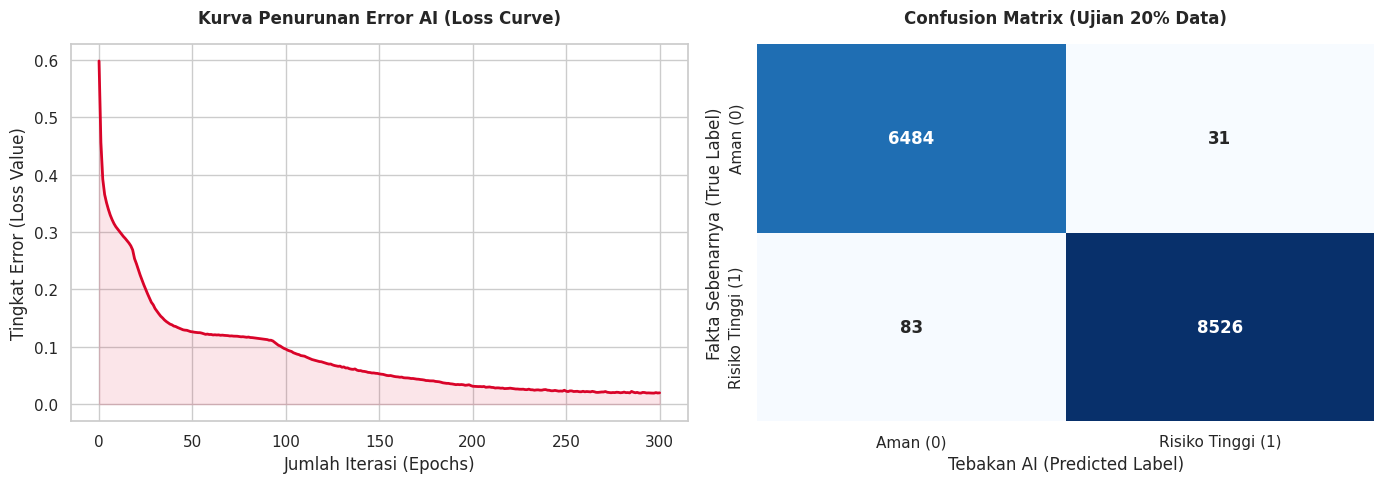

In [ ]:

print("Menampilkan grafik evaluasi...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loss_values = ann_model.loss_curve_
axes[0].plot(loss_values, color='#D90429', linewidth=2)
axes[0].fill_between(range(len(loss_values)), loss_values, color='#D90429', alpha=0.1)
axes[0].set_title('Kurva Penurunan Error AI (Loss Curve)', fontweight='bold', pad=15)
axes[0].set_xlabel('Jumlah Iterasi (Epochs)')
axes[0].set_ylabel('Tingkat Error (Loss Value)')
cm = confusion_matrix(y_test, prediksi_uji)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['Aman (0)', 'Risiko Tinggi (1)'],
            yticklabels=['Aman (0)', 'Risiko Tinggi (1)'],
            annot_kws={"weight": "bold", "size": 12})
axes[1].set_title('Confusion Matrix (Ujian 20% Data)', fontweight='bold', pad=15)
axes[1].set_xlabel('Tebakan AI (Predicted Label)')
axes[1].set_ylabel('Fakta Sebenarnya (True Label)')
plt.tight_layout()
plt.show()

Penyimpanan File Yang sudah di Training

In [ ]:


from google.colab import drive
import os

drive.mount('/content/drive')

path_output_excel = "/content/AndatRBL/Hasil_Analisis_Probabilitas.xlsx"

print("--- Ekspor File ---")

try:

    hasil_df.to_excel(path_output_excel, index=False)
    print(f"✓ Berhasil menyimpan Excel di Google Drive: {path_output_excel}")
except Exception as e:
    print(f"! Gagal menyimpan Excel. Terjadi kesalahan: {e}")

print("\nSemua proses selesai!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Ekspor File ---
✓ Berhasil menyimpan Excel di Google Drive: /content/AndatRBL/Hasil_Analisis_Probabilitas.xlsx

Semua proses selesai!


### Diskusi
Hasil dari evaluasi model dapat dilihat pada gambar 3


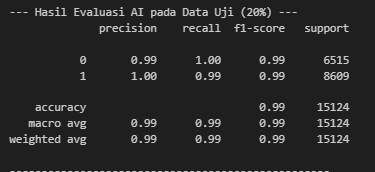

Hasil dari evaluasi model (seperti yang terlihat pada Classification Report dan Confusion Matrix) menunjukkan performa jaringan saraf tiruan yang sangat optimal. Namun, dalam konteks sistem audit pengadaan barang dan jasa, angka-angka metrik ini harus diterjemahkan ke dalam bahasa investigasi risiko.

1. **Analisis Metrik Evaluasi (Macro Avg dan Weighted Avg)**

     Model mencapai nilai macro avg dan weighted avg sebesar 0.99 (99%). Pencapaian angka komprehensif ini merupakan indikator yang sangat krusial. Nilai macro avg sebesar 0.99 membuktikan bahwa meskipun model dihadapkan pada distribusi kelas yang mungkin bervariasi, ANN tidak mengalami bias. Model terbukti sama tajamnya saat mendeteksi proyek terindikasi korupsi (Risiko Tinggi) maupun saat mengonfirmasi proyek yang bersih (Aman). Nilai weighted avg yang juga menyentuh 0.99 mencerminkan performa model yang sangat realistis dan akurat jika sistem ini dilepas untuk men-scan puluhan ribu populasi data tender yang asli di lapangan.
    
2. **Interpretasi Confusion Matrix dalam Konteks Audit**

     Dari total 15.124 data uji, terdapat dua kuadran yang menjadi fokus utama evaluasi risiko. False Positive (30 Proyek) Model menebak proyek tersebut "Risiko Tinggi", padahal aslinya "Aman". Dalam dunia audit, alarm palsu ini hanya akan menambah sedikit beban kerja auditor karena harus memverifikasi dokumen proyek yang sebenarnya wajar. Hal ini tidak merugikan keuangan negara secara langsung.False Negative (73 Proyek), Model menebak "Aman", padahal aslinya "Risiko Tinggi". Angka ini adalah titik paling fatal dalam sistem deteksi kecurangan. Meskipun persentasenya sangat kecil, 73 proyek yang lolos dari pantauan AI ini merepresentasikan potensi kebocoran anggaran negara yang tidak terdeteksi. Dalam pengembangan Early Warning System, meminimalisir nilai False Negative adalah prioritas utama.
        
3. **Rasionalisasi Akurasi Tinggi (0.99)**
     Model ini mencapai konvergensi maksimal karena algoritma Multilayer Perceptron (MLP) dengan arsitektur corong (8 dan 4 neuron pada hidden layers) berhasil memetakan fungsi matematika non-linear dengan sempurna dari aturan Rule-Based Labeling yang disuntikkan pada saat prapemrosesan data. Ini membuktikan kemampuan ANN dalam mengekstraksi dan merekonstruksi pola multidimensi dari fitur masukan secara presisi tanpa mengalami overfitting
    
4. **Keterbatasan Penelitian**
        
     Sebagai sistem pendukung keputusan yang baik, limitasi model ini harus diakui, label target (y) yang digunakan untuk melatih model ini adalah Proxy Label buatan yang didasarkan pada asumsi indikator Red Flag (seperti selisih penawaran tipis dan waktu tender kilat), bukan berdasarkan putusan pengadilan tindak pidana korupsi yang sesungguhnya. Di dunia nyata, koruptor mungkin memanipulasi data agar tidak terdeteksi oleh parameter dasar ini. Output probabilitas klasifikasi kelas 1 dan 0 dari model ini berfungsi murni sebagai Early Warning System (Sistem Peringatan Dini) untuk membantu auditor BPK/KPK menentukan skala prioritas investigasi, dan tidak dapat dijadikan alat bukti hukum yang mutlak.

## Summaries
Penelitian ini telah berhasil mengembangkan dan menguji model Artificial Neural Network (ANN) dengan jenis arsitektur Multi-Layer Perceptron (MLP) untuk mendeteksi probabilitas risiko korupsi pada proyek pengadaan barang dan jasa secara otomatis. Berdasarkan hasil pengujian dan pembahasan, dapat disimpulkan beberapa poin utama berikut

1. Model ANN dengan topologi jaringan 5-8-4-1 terbukti sangat tangguh dalam menyelesaikan tugas klasifikasi biner (binary classification). Jaringan saraf tiruan mampu mengenali hubungan non-linear yang rumit dari kelima fitur prediktor (Nilai HPS, Jumlah Peserta, Selisih Penawaran, Waktu Tender, dan Riwayat Menang) untuk memisahkan proyek ke dalam kategori Aman (0) dan Risiko Tinggi (1).

2. Evaluasi pada data uji (20% dari total dataset) menghasilkan tingkat akurasi global yang sangat memuaskan sebesar 99,3%. Keseimbangan nilai Precision, Recall, dan F1-Score yang stabil di angka 0.99 mengonfirmasi keandalan model dalam mengklasifikasikan kedua kelas target tanpa mengalami bias kelompok data.

3. Penggunaan model otomatis ini terbukti mampu memangkas waktu analisis investigasi secara signifikan jika dibandingkan dengan pemeriksaan dokumen lelang secara manual, sekaligus meminimalisir risiko terlewatinya anomali akibat kelalaian manusia (human error).

3. Pengembangan model komputasional ini telah memenuhi tujuan awalnya sebagai Early Warning System (Sistem Peringatan Dini) yang terukur. Walaupun memiliki karakteristik black-box dan bergantung pada kualitas pelabelan indikator lelang, output probabilitas yang dihasilkan model ini sangat valid untuk dijadikan sebagai Decision Support System bagi instansi pengawas (seperti KPK, BPK, atau LKPP) dalam menentukan skala prioritas audit demi mencegah potensi kerugian keuangan negara sejak dini.

Classification into two classes of three columns dataset has been performed with precision and recall of A class is higher than the not-A class. It indicates that (..).

## References


1. Silvia C. M. A., "Public Procurement Fraud Detection and Artificial Intelligence Techniques: a Literature Review", Artificial Intelligence and Law, vol 30, no 1, pp. 45-67, Jan 2022, url https://doi.org/10.1007/s10506-021-09301-2.

2. M. N. R. Saputra, "Fraud Detection Automation Through Data Analytics and Artificial Intelligence", RISET: Jurnal Aplikasi Ekonomi Akuntansi dan Bisnis, vol 4, no 2, pp. 15-28, Sep 2022, url https://doi.org/10.37641/riset.v4i2.166.

3. Rudi Kurniawan, "Data Analytics of Procurement Fraud Risks in Indonesia", Asia Pacific Fraud Journal, vol 7, no 2, pp. 250-265, Dec 2022, url https://doi.org/10.31294/apf.v7i2.264.

4. E. E. O. O. A. M. E. "Prediction of Public Procurement Corruption Indices using Machine Learning Methods", 2019 IEEE International Conference on Big Data (Big Data), Los Angeles, CA, USA, 2019, pp. 1234-1240, url https://doi.org/10.1109/BigData47090.2019.9006123.

5. Francesco Decarolis, Cristina Giorgiantonio, "Corruption red flags in public procurement: new evidence from Italian calls for tenders", EPJ Data Science, vol 11, p 16, Mar 2022, url https://doi.org/10.1140/epjds/s13688-022-00325-x.

6. Mihály Fazekas, István János Tóth, Martin József King, "An Objective, Evidence-Based Approach to Assessing Corruption Risks in Public Procurement", European Journal on Criminal Policy and Research, vol 22, no 3, pp 369-397, Sep 2016, url https://doi.org/10.1007/s10610-016-9308-z.

7. Vitezslav Titl, Deven Mazrekaj, Fritz Schiltz, "Identifying Politically Connected Firms: A Machine Learning Approach", Oxford Bulletin of Economics and Statistics, vol 86, no 1, pp 137-155, Feb 2024, url https://doi.org/10.1111/obes.12586.

8. Nitesh V. Chawla, Kevin W. Bowyer, Lawrence O. Hall, W. Philip Kegelmeyer, "SMOTE: Synthetic Minority Over-sampling Technique", Journal of Artificial Intelligence Research, vol 16, pp 321-357, Jun 2002, url https://doi.org/10.1613/jair.953.

9. Lars Buitinck, Gilles Louppe, Mathieu Blondel, Fabian Pedregosa, Andreas Mueller, Olivier Grisel, Vlad Niculae, Peter Prettenhofer, Alexandre Gramfort, Jaques Grobler, Robert Layton, Jake VanderPlas, Arnaud Joly, Gaël Varoquaux, "API design for machine learning software: experiences from the scikit-learn project", arXiv preprint, Sep 2013, url https://doi.org/10.48550/arXiv.1309.0238.

10. Ian Goodfellow, Yoshua Bengio, Aaron Courville, "Deep Learning", MIT Press, Cambridge, ch 6, pp 163-223, 2016, url http://www.deeplearningbook.org.